# 04: When Does a Pattern Become a Thing?

Use Game of Life gliders to separate material identity from organizational identity.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BOOK_FIG_DIR = ROOT / "static" / "images" / "books" / "digital-life"
FIG_DIR = ROOT / "notebooks" / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180


In [2]:
def life_step(state: np.ndarray) -> np.ndarray:
    neighbors = (
        np.roll(np.roll(state,  1, axis=0),  1, axis=1)
        + np.roll(state,  1, axis=0)
        + np.roll(np.roll(state,  1, axis=0), -1, axis=1)
        + np.roll(state,  1, axis=1)
        + np.roll(state, -1, axis=1)
        + np.roll(np.roll(state, -1, axis=0),  1, axis=1)
        + np.roll(state, -1, axis=0)
        + np.roll(np.roll(state, -1, axis=0), -1, axis=1)
    )
    born = (state == 0) & (neighbors == 3)
    survive = (state == 1) & ((neighbors == 2) | (neighbors == 3))
    return (born | survive).astype(np.uint8)


def run_life(initial_state: np.ndarray, generations: int) -> np.ndarray:
    state = initial_state.copy()
    history = np.zeros((generations, *state.shape), dtype=np.uint8)
    history[0] = state
    for t in range(1, generations):
        state = life_step(state)
        history[t] = state
    return history


GLIDER = np.array([[0,1,0],[0,0,1],[1,1,1]], dtype=np.uint8)
BLOCK = np.array([[1,1],[1,1]], dtype=np.uint8)
BLINKER = np.array([[1,1,1]], dtype=np.uint8)


def empty_world(size: int) -> np.ndarray:
    return np.zeros((size, size), dtype=np.uint8)


def place(world, pattern, row, col):
    h, w = pattern.shape
    world[row:row+h, col:col+w] = pattern


def centroid(state):
    pos = np.argwhere(state == 1)
    return None if len(pos) == 0 else tuple(pos.mean(axis=0))


def show_life(state, title):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(state, cmap="binary", interpolation="nearest", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()


In [3]:
EXPERIMENT = {"world": 60, "glider_start": (5, 5), "generations": 100, "period": 4, "displacement": (1, 1), "boundary": "periodic"}
EXPERIMENT


{'world': 60,
 'glider_start': (5, 5),
 'generations': 100,
 'period': 4,
 'displacement': (1, 1),
 'boundary': 'periodic'}

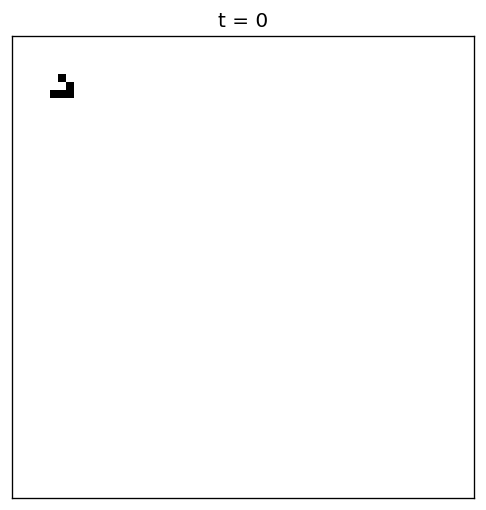

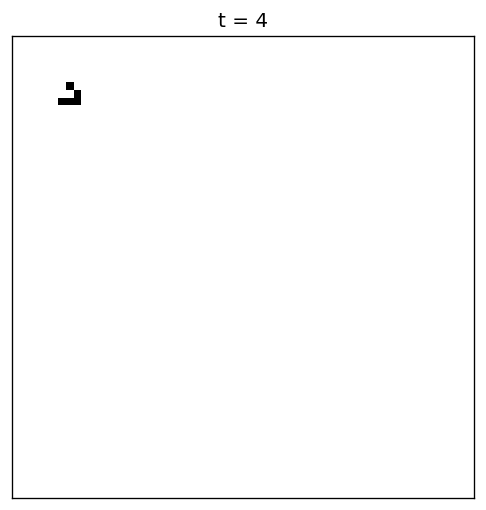

In [4]:
world = empty_world(EXPERIMENT["world"]); place(world, GLIDER, *EXPERIMENT["glider_start"]); history = run_life(world, EXPERIMENT["generations"])
show_life(history[0], "t = 0"); show_life(history[4], "t = 4")


## Measurement: recurrence up to translation


In [5]:
shifted = np.roll(np.roll(history[0], 1, axis=0), 1, axis=1)
{"whole_grid_equal_t0_t4": bool(np.array_equal(history[0], history[4])), "equal_after_expected_translation": bool(np.array_equal(shifted, history[4]))}


{'whole_grid_equal_t0_t4': False, 'equal_after_expected_translation': True}

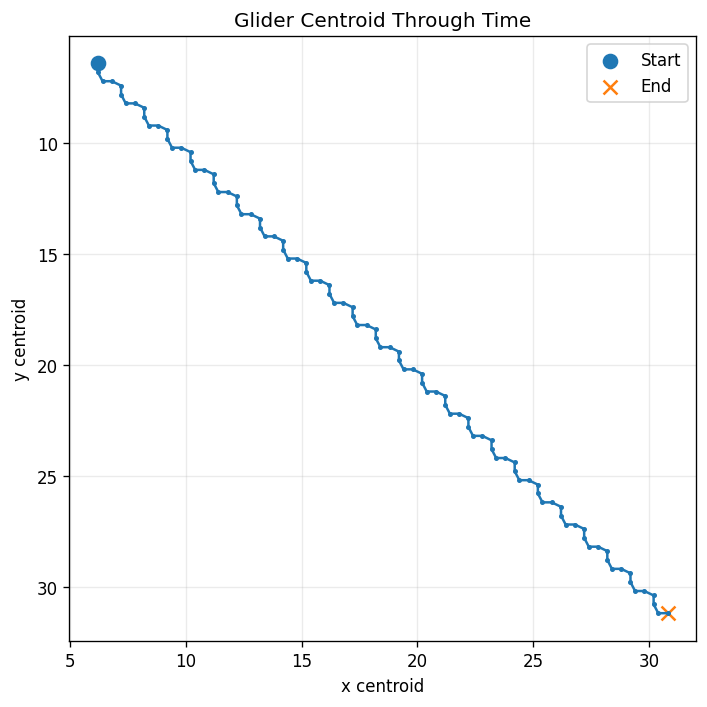

In [6]:
points = np.array([centroid(s) for s in history if centroid(s) is not None])
fig, ax = plt.subplots(figsize=(6,6)); ax.plot(points[:,1], points[:,0], marker="o", markersize=2); ax.scatter(points[0,1], points[0,0], s=70, label="Start"); ax.scatter(points[-1,1], points[-1,0], marker="x", s=70, label="End"); ax.invert_yaxis(); ax.legend(); ax.grid(alpha=.25); ax.set(title="Glider Centroid Through Time", xlabel="x centroid", ylabel="y centroid"); fig.tight_layout(); fig.savefig(FIG_DIR / "ch04-glider-centroid.png", bbox_inches="tight"); plt.show()


## Control/comparison: fixed, periodic, and translating persistence


In [7]:
patterns = [("Block", BLOCK), ("Blinker", BLINKER), ("Glider", GLIDER)]
for name, pat in patterns:
    w = empty_world(21); place(w, pat, 10 - pat.shape[0]//2, 10 - pat.shape[1]//2); h = run_life(w, 5)
    print(name, [int(s.sum()) for s in h], "centroids", [centroid(s) for s in h[:5]])


Block [4, 4, 4, 4, 4] centroids [(np.float64(9.5), np.float64(9.5)), (np.float64(9.5), np.float64(9.5)), (np.float64(9.5), np.float64(9.5)), (np.float64(9.5), np.float64(9.5)), (np.float64(9.5), np.float64(9.5))]
Blinker [3, 3, 3, 3, 3] centroids [(np.float64(10.0), np.float64(10.0)), (np.float64(10.0), np.float64(10.0)), (np.float64(10.0), np.float64(10.0)), (np.float64(10.0), np.float64(10.0)), (np.float64(10.0), np.float64(10.0))]
Glider [5, 5, 5, 5, 5] centroids [(np.float64(10.4), np.float64(10.2)), (np.float64(10.8), np.float64(10.2)), (np.float64(11.2), np.float64(10.4)), (np.float64(11.2), np.float64(10.8)), (np.float64(11.4), np.float64(11.2))]


## What the evidence supports

A glider is useful as a pattern-level entity under a defined criterion: localized state recurs after four generations up to translation by (+1,+1). The cells did not move; the organization was reconstructed at new coordinates.

## Provenance

**Book chapter**

`content/books/digital-life/04-when-does-a-pattern-become-a-thing/index.md`

**Research scripts used**

- `scripts/books/digital-life/ch04_pattern_becomes_a_thing.py`

**Book figures reproduced**

- `static/images/books/digital-life/ch04-glider-centroid.png`

The notebook recomputes the glider dynamics and measurements inline. The chapter GIFs and persistence filmstrip are generated by the source script.
